In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
raw_data, raw_labels = mnist["data"], mnist["target"]

In [4]:
print(mnist["DESCR"])

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

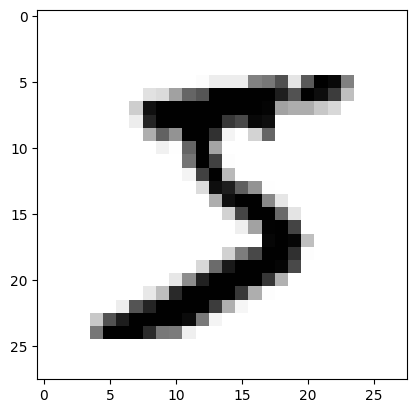

In [5]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
some_digit = raw_data[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation="nearest")
plt.axis("on")
plt.grid(False)
plt.show()

In [6]:
raw_labels[11]

'5'

In [7]:
raw_labels = raw_labels.astype(np.uint8)

In [8]:
raw_labels[11]

5

In [9]:
X_train, X_test, y_train, y_test = raw_data[:60000], raw_data[60000:], raw_labels[:60000], raw_labels[60000:]


In [10]:
y_train_5 : bool = []
y_test_5 : bool = []
for i in range(len(y_train)):
    if y_train[i] == 5:
        y_train_5.append(True) 
    else:
        y_train_5.append(False)

In [11]:
for i in range(len(y_test)):
    if y_test[i] == 5:
        y_test_5.append(True)
    else:
        y_test_5.append(False)

In [12]:
y_train_5_book = (y_train == 5)
y_test_5_book = (y_test == 5)
print(type(y_train_5))
print(type(y_test_5_book))
print(type(y_train_5_book))
print(type(y_test_5))

<class 'list'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'list'>


In [13]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5_book)

SGDClassifier(random_state=42)

In [14]:
a_number = X_train[:15]
print(type(a_number))
sgd_clf.predict(a_number)

<class 'numpy.ndarray'>


array([ True, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False])

In [19]:
import joblib
joblib.dump(sgd_clf, "sgd_model_predict_5.pkl")

['sgd_model_predict_5.pkl']

In [18]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_index, test_index in skfolds.split(X_train, y_train_5_book):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5_book[train_index]
    X_test_folds = X_train[test_index]
    y_test_folds = y_train_5_book[test_index]
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)
    print(n_correct/len(y_pred))

0.9669
0.91625
0.96785


In [21]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5_book, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [25]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5_book, cv=3)

array([ True, False, False, ...,  True, False, False])

In [23]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5_book, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

(60000,)